# Research Proposal: Modeling Daily Parking Ticket Counts in Milwaukee

### John Eckberg

## Overview
[Milwaukee plans 65,000 more parking tickets, longer meter hours to fill transportation budget gap](https://www.jsonline.com/story/news/local/milwaukee/2025/10/21/milwaukee-aims-for-550k-parking-tickets-longer-meter-hours-in-2026/86817755007/) The city of Milwaukee relies on parking ticket revenue in order to fill budget gaps, a pressing issue given the [current deficit](https://urbanmilwaukee.com/2025/03/12/mke-county-county-faces-47-million-2026-budget-deficit/) the county is facing.
This project plans to examine how daily parking ticket activity in Milwaukee varies across time and environmental conditions. Using parking citation records obtained through a Freedom of Information Act request (2014–2022), I propose to model daily ticket counts and evaluate whether temporal, weather, and holiday-related factors explain variation in enforcement volume.

## Research Question
What is the daily rate of parking tickets issued in Milwaukee, and which factors most strongly influence that rate (if any)? In particular, I propose to test whether day of week, month/seasonality, holidays, and precipitation are associated with higher or lower daily ticket counts, including by citation type.

## Hypothesis
- Null Hypothesis: day of week, month/seasonality, holidays, and precipitation do not affect daily ticket counts.
- Alternative Hypothesis: at least one temporal or environmental factor affects daily ticket counts.

## Data Sources
- **Parking citations:** Milwaukee parking ticket records, initially loaded for 2014, with fields including `ISSUENO`, `ISSUEDATE`, `LOCATIONDESC1`, and `VIODESCRIPTION`.
- **Holiday data:** U.S. holiday dates (2004–2021) pulled from Kaggle to identify atypical traffic/parking demand days.
- **Weather data:** Open-Meteo daily weather for Milwaukee, including maximum temperature, minimum temperature, precipitation, and snowfall.


## Method
The analysis would likely focus on a geographically meaningful subset of Milwaukee (e.g., downtown, Lower East Side, Deer District). Because the response variable is a daily count, I propose that the initial model choice would be a Poisson regression GLM.

### Currently Planned Features
- **Calendar effects:** day of week, month, weekend indicator, and potential seasonal terms.
- **Cyclical time encoding:** sine/cosine transforms for month and day-of-week to preserve circular structure.
- **Holiday effects:** binary `is_holiday` indicator, one-hot encoding for major holiday names.
- **Weather exposure:** `max_temp`, `min_temp`, `precipitation`, and `snowfall`; optional threshold features (e.g., heavy precipitation day).
- **Autocorrelation:** lagged ticket count features (e.g., 1-day and 7-day lags) and short rolling averages.



In [18]:
import pandas as pd
import requests
import kagglehub 
import openpyxl
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Loading in the parking data [All Years now]  --  Runs in about 10 mins

#tickets_df = pd.read_excel("data/tickets_csv/2014_parking_citations_issued_open_records_request.xlsx")
data_dir = Path("data/tickets_csv")

tickets_dfs = []

for file in sorted(data_dir.glob("*.xlsx")):
    df = pd.read_excel(file)
    tickets_dfs.append(df)

tickets = pd.concat(tickets_dfs, ignore_index=True)

tickets.sample(5)

,ISSUENO,ISSUEDATE,LOCATIONDESC1,VIODESCRIPTION
206487,476915950,2014-05-01,2519 W MELVINA ST,PARKED IN CROSSWALK
4637446,129821414,2022-06-17,935 N 26TH ST,NIGHT PARKING - WRONG SIDE
180174,476633183,2014-04-15,1814 N WATER ST,NIGHT PARKING
909631,485068021,2015-06-06,1704 N MARSHALL ST,NIGHT PARKING
3408389,116718906,2019-08-20,3449 N CRAMER ST,PARKING IN EXCESS OF 48 HOURS


In [8]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 4865096 entries, 0 to 4865095
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   ISSUENO         int64         
 1   ISSUEDATE       datetime64[us]
 2   LOCATIONDESC1   object        
 3   VIODESCRIPTION  str           
dtypes: datetime64[us](1), int64(1), object(1), str(1)
memory usage: 148.5+ MB


In [9]:
# load in holiday data (https://www.kaggle.com/datasets/donnetew/us-holiday-dates-2004-2021)

path = kagglehub.dataset_download("donnetew/us-holiday-dates-2004-2021")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mathewsj\.cache\kagglehub\datasets\donnetew\us-holiday-dates-2004-2021\versions\1


In [10]:
#holidays_df = pd.read_csv("C:/Users/eckbergj/.vscode/Milwaukee-Ticket-Data-Analysis/data/US Holiday Dates (2004-2021).csv")
holidays_df = pd.read_csv("data/US Holiday Dates (2004-2021).csv")

holidays_df.head(10)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006
3,2007-07-04,4th of July,Wednesday,7,4,2007
4,2008-07-04,4th of July,Friday,7,4,2008
5,2009-07-04,4th of July,Saturday,7,4,2009
6,2010-07-04,4th of July,Sunday,7,4,2010
7,2011-07-04,4th of July,Monday,7,4,2011
8,2012-07-04,4th of July,Wednesday,7,4,2012
9,2013-07-04,4th of July,Thursday,7,4,2013


In [11]:
# weather data (https://open-meteo.com/)  [extended from 2012 - 2022]
test_data = requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=43.0389&longitude=-87.9065&start_date=2014-01-01&end_date=2022-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum&timezone=America%2FChicago")
test_data_json = test_data.json()

# minor cleaning of the weather data to get it into a dataframe
weather_df = pd.DataFrame(test_data_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df = weather_df.rename(columns={'time': 'date', 'temperature_2m_max': 'max_temp', 'temperature_2m_min': 'min_temp', 'precipitation_sum': 'precipitation','snowfall_sum': 'snowfall'})
weather_df.sample(10)


,date,max_temp,min_temp,precipitation,snowfall
1013,2016-10-10,16.6,12.8,0.0,0.00
2269,2020-03-19,8.6,0.8,10.6,0.00
3029,2022-04-18,5.6,0.3,7.6,3.92
2602,2021-02-15,-13.4,-20.7,2.7,1.89
673,2015-11-05,16.5,13.5,0.2,0.00
3156,2022-08-23,28.4,17.5,0.0,0.00
1422,2017-11-23,6.2,-1.0,0.0,0.00
2345,2020-06-03,29.0,19.1,1.8,0.00
1894,2019-03-10,6.8,-2.1,0.2,0.00
677,2015-11-09,10.4,5.0,0.0,0.00


In [12]:
# clean and align date keys before joining
tickets_clean = tickets.copy()
holidays_clean = holidays_df.copy()
weather_clean = weather_df.copy()

# Datetime object
tickets_clean['join_date'] = pd.to_datetime(tickets_clean['ISSUEDATE'], errors='coerce').dt.normalize()
holidays_clean['join_date'] = pd.to_datetime(holidays_clean['Date'], errors='coerce').dt.normalize()
weather_clean['join_date'] = pd.to_datetime(weather_clean['date'], errors='coerce').dt.normalize()


# merge tickets with holidays and weather on a consistent datetime key
combined_tickets_and_holidays_df = pd.merge(
    tickets_clean,
    holidays_clean,
    how='left',      # SWITCHED from 'inner' to 'left' to keep all tickets, even those without a holiday match (-> 'NAN')
    on='join_date'
 )

combined_all_df = pd.merge(
    combined_tickets_and_holidays_df,
    weather_clean,
    how='left',
    on='join_date',
    suffixes=('_holiday', '_weather')
 )

# Dropping REDUNDANT columns from the joins and the Holiday data (since many become NAN, will grab the same date info later on)
combined_all_df = combined_all_df.drop(columns=['ISSUEDATE','Date','date','WeekDay', 'Month', 'Day', 'Year'])

# sample of the combined dataframe
combined_all_df[combined_all_df['Holiday'].notnull()].sample(5)
#combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall
636203,481924925,4425 N 73RD ST,NIGHT PARKING - WRONG SIDE,2014-12-31,New Year’s Eve,-7.0,-13.8,0.0,0.0
1654748,493349721,3042 N 1ST ST,NIGHT PARKING,2016-09-03,Labor Day Weekend,21.6,18.3,0.0,0.0
412583,479260445,1329 W WINDLAKE AVE,PARKING IN EXCESS OF 24 HOURS,2014-08-31,Labor Day Weekend,24.5,18.8,0.7,0.0
1654934,663043382,1415 N FRANKLIN PL,UNREGISTERED/ IMPROPERLY REGISTERED VEHICLE,2016-09-03,Labor Day Weekend,21.6,18.3,0.0,0.0
2929597,111771715,2973 N CRAMER ST,PARKED IN EXCESS OF 1 HOUR PROHIBITED,2018-10-08,Columbus Day,27.1,14.2,10.6,0.0


### Feature Engineering

In [13]:
# Use Pandas DateTime to get WeekDay, Day (number), Month, Year from each ticket's join_date (ISSUEDATE)
combined_all_df['WeekDay'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day_name()
combined_all_df['Day'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day
combined_all_df['Month'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.month
combined_all_df['Year'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.year

combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,Day,Month,Year
434441,479509671,2625 W NATIONAL AVE,PARKED POSTED PRIVATE PROPERTY,2014-09-11,NaN,12.7,10.3,0.0,0.0,Thursday,11,9,2014
2162065,104042551,615 E WELLS ST,METER PARKING VIOLATION,2017-06-28,NaN,24.8,14.3,23.4,0.0,Wednesday,28,6,2017
3873893,121616784,1302 N JACKSON ST,NIGHT PARKING,2020-11-25,Thanksgiving Eve,6.1,5.1,13.6,0.0,Wednesday,25,11,2020
2945589,111891743,1222 N 11TH ST,METER PARKING VIOLATION,2018-10-17,NaN,8.8,2.1,0.0,0.0,Wednesday,17,10,2018
2903594,111576441,637 S 9TH ST,PARKED MORE THAN 12 INCHES FROM CURB,2018-09-21,NaN,27.3,11.5,1.9,0.0,Friday,21,9,2018


In [14]:
# See what Violation categories can be made out of the data
combined_all_df.value_counts('VIODESCRIPTION')

VIODESCRIPTION
NIGHT PARKING                                1527527
METER PARKING VIOLATION                       810877
NIGHT PARKING - WRONG SIDE                    748186
PARKING PROHIBITED BY OFFICIAL SIGN           259562
IMPROPERLY DISPLAYED VEHICLE REGISTRATION     203366
                                              ...   
TESTING IVR                                        2
TEST VIOLATION                                     1
PARKED IN RECREATIONAL AREA                        1
PARKED IN EXCESS OF 24 HOURS PROHIBITED            1
EXCEED 10-HOUR LIMIT AT METER                      1
Name: count, Length: 90, dtype: int64

In [15]:
# Feature for  Winter Storm? Inclement Weather?  Threshold can be adjusted 
combined_all_df['is_snow_emergency'] = ((combined_all_df['VIODESCRIPTION'].str.lower().str.contains('snow|emergency')) |      # in-line OR
                                        (combined_all_df['snowfall'] > 3.0)).astype(int)

# Heavy Rain?
combined_all_df['is_heavy_rain'] = (combined_all_df['precipitation'] > 2.0).astype(int)

# Meter Violation?
combined_all_df['is_meter_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('meter').astype(int) # 1 = Meter Violation, 0 = Not a Meter Violation

# Night Violation?
combined_all_df['is_night_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('night').astype(int) # 1 = Night Violation, 0 = Not a Night Violation

# Registration Violation?
combined_all_df['is_registration_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('registration|unregistered').astype(int) # 1 = Registration Violation, 0 = Not a Registration Violation

# Time Violation ?
combined_all_df['is_time_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('excess|hours|time').astype(int) # 1 = Time Violation, 0 = Not a Time Violation

# Weekend Violation?  Could add Friday as well if wanted
combined_all_df['is_weekend_ticket'] = combined_all_df['WeekDay'].str.lower().str.contains('saturday|sunday').astype(int) # 1 = Weekend Violation, 0 = Not a Weekend Violation


# Create a binary holiday flag immediately after the merge
# If 'Holiday' is not null, it becomes 1. If it is null, it becomes 0.
combined_all_df['is_holiday'] = combined_all_df['Holiday'].notnull().astype(int)

combined_all_df[combined_all_df['is_holiday'] == 1].sample(8)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,...,Month,Year,is_snow_emergency,is_heavy_rain,is_meter_ticket,is_night_ticket,is_registration_ticket,is_time_ticket,is_weekend_ticket,is_holiday
4137897,124409224,1410 W EDGERTON AV,NIGHT PARKING,2021-06-19,Juneteenth,23.5,15.1,5.2,0.00,Saturday,...,6,2021,0,1,0,1,0,0,1,1
3059924,113204685,706 W WISCONSIN AV,TOW-AWAY ZONE (POSTED),2019-01-01,New Year's Day,-0.3,-5.8,0.2,0.21,Tuesday,...,1,2019,0,0,0,0,0,0,0,1
3002525,112535102,5910 N 35TH ST,PARKING IN EXCESS OF 24 HOURS,2018-11-21,Thanksgiving Eve,-0.8,-2.9,0.0,0.00,Wednesday,...,11,2018,0,0,0,0,0,1,0,1
2929089,111798853,3054 N FARWELL AV,RESIDENTIAL PARKING PROGRAM,2018-10-08,Columbus Day,27.1,14.2,10.6,0.00,Monday,...,10,2018,0,1,0,0,0,0,0,1
1791784,100371456,331 W WISCONSIN AV,TOW-AWAY ZONE (POSTED),2016-11-23,Thanksgiving Eve,6.5,4.2,7.5,0.42,Wednesday,...,11,2016,0,1,0,0,0,0,0,1
2361455,106087166,10311 W CONGRESS ST,NIGHT PARKING,2017-11-11,Veterans Day,1.5,-2.8,0.0,0.00,Saturday,...,11,2017,0,0,0,1,0,0,1,1
4021703,123086655,5515 W LOCUST ST,PARKED ON SIDEWALK (SIDEWALK AREA),2021-04-04,Western Easter,17.0,4.3,0.0,0.00,Sunday,...,4,2021,0,0,0,0,0,0,1,1
2708400,109475586,2236 S 14TH ST,PARKED WITHIN 4 FEET OF DRIVE OR ALLEY,2018-05-28,Memorial Day,29.2,14.9,0.1,0.00,Monday,...,5,2018,0,0,0,0,0,0,0,1


In [16]:
# Compressing into a Daily Format: Row per Day, with Ticket Counts and Weather/Holiday Features to be able to then predict the Daily Rate of parking tickets (and the features that affect that)
daily_summary_df = combined_all_df.groupby('join_date').agg(
    # Target Variable: COUNT of the total tickets issued that day
    total_tickets=('ISSUENO', 'count'),

    # Dataset Weather Features:
    max_temp = ('max_temp', 'max'),
    min_temp = ('min_temp', 'min'),
    precipitation = ('precipitation', 'max'),
    snowfall = ('snowfall', 'max'),
    is_snow_emergency = ('is_snow_emergency', 'max'),
    is_heavy_rain = ('is_heavy_rain', 'max'),

    # Calendar Features:
    WeekDay = ('WeekDay', 'first'),
    Year = ('Year', 'first'),
    Month = ('Month', 'first'),
    Day = ('Day', 'first'),
    is_weekend = ('is_weekend_ticket', 'max'),
    is_holiday = ('is_holiday', 'max'),

    # Count up the number of each Binary Feature type per day!
    meter_tickets_count = ('is_meter_ticket', 'sum'),
    night_tickets_count = ('is_night_ticket', 'sum'),
    registration_tickets_count = ('is_registration_ticket', 'sum'),
    time_tickets_count = ('is_time_ticket', 'sum')
).reset_index()

daily_summary_df.sample(10)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,Month,Day,is_weekend,is_holiday,meter_tickets_count,night_tickets_count,registration_tickets_count,time_tickets_count
2682,2021-05-06,2209,11.7,7.0,7.0,0.00,0,1,Thursday,2021,5,6,0,0,289,1323,160,161
1709,2018-09-06,2875,19.7,15.5,1.0,0.00,0,0,Thursday,2018,9,6,0,0,375,1532,337,259
2660,2021-04-14,2387,6.7,0.4,0.0,0.00,0,0,Wednesday,2021,4,14,0,0,299,1531,122,173
126,2014-05-07,2500,9.4,5.3,12.7,0.00,0,1,Wednesday,2014,5,7,0,0,677,975,204,235
3206,2022-10-12,1852,19.7,9.7,8.9,0.00,0,1,Wednesday,2022,10,12,0,0,301,1043,122,134
1425,2017-11-26,197,7.9,-4.3,0.0,0.00,0,0,Sunday,2017,11,26,1,0,0,1,116,2
3190,2022-09-26,388,15.6,10.0,0.0,0.00,0,0,Monday,2022,9,26,0,0,82,108,63,5
1088,2016-12-24,1053,1.4,0.5,0.0,0.07,0,0,Saturday,2016,12,24,1,1,65,829,33,43
2715,2021-06-08,2389,27.7,18.2,10.4,0.00,0,1,Tuesday,2021,6,8,0,0,344,1555,144,78
752,2016-01-23,2679,-0.5,-5.7,0.0,0.07,0,0,Saturday,2016,1,23,1,0,125,2095,91,170


### Visualization

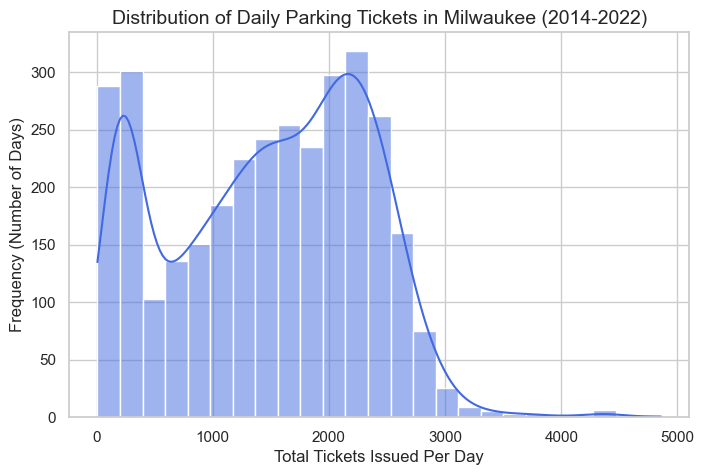

In [42]:
sns.set_theme(style="whitegrid")

# Histogram Plot of the Distribution of Total Daily Tickets -> show Right Skewed Tail
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_df['total_tickets'], bins=25, kde=True, color='royalblue')

plt.title("Distribution of Daily Parking Tickets in Milwaukee (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()

#### Temporal (Time) Features

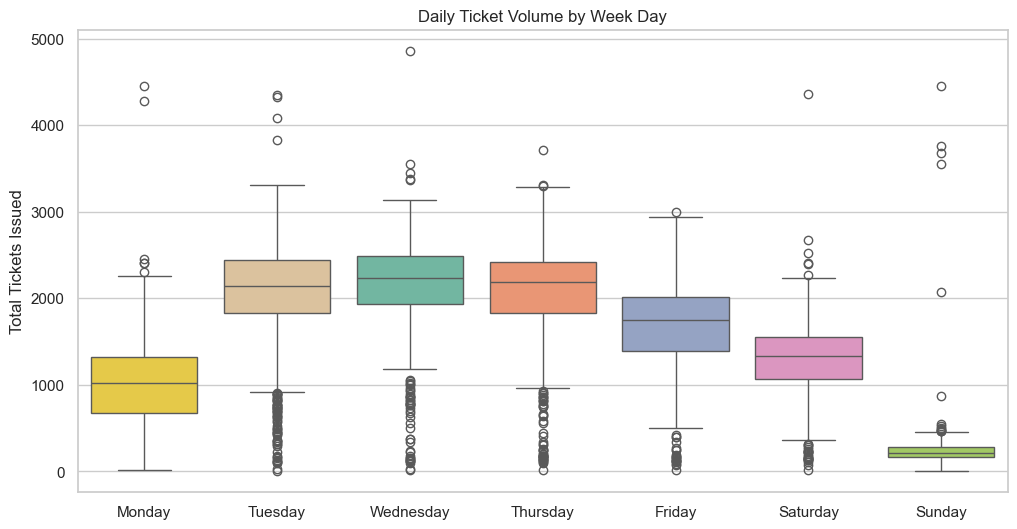

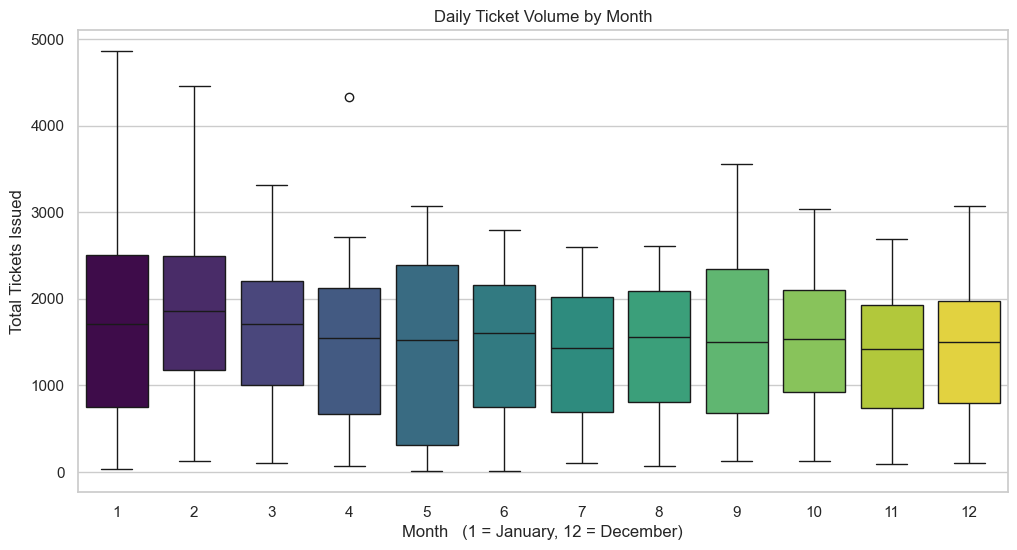

In [85]:
# WeekDay	Year	Month	Day	 is_weekend	is_holiday  
temporal_cols = ['WeekDay', 'Year', 'Month', 'Day', 'is_weekend', 'is_holiday']

# WeekDay vs. Total_Tickets (Daily Count) -> Cat. vs. Num - Boxplot
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(x='WeekDay', y='total_tickets', order=days_ordered, data=daily_summary_df, hue='WeekDay', palette='Set2')
plt.title("Daily Ticket Volume by Week Day")
plt.xlabel("")
plt.ylabel("Total Tickets Issued")
plt.show()

# Month vs. Total_Ticekts
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='total_tickets',  data=daily_summary_df, hue='Month', palette='viridis', legend=False)
plt.title("Daily Ticket Volume by Month")
plt.xlabel("Month   (1 = January, 12 = December)")
plt.ylabel("Total Tickets Issued")
plt.show()


Sunday is very CLEARLY the least Ticketed day, followed by Monday!

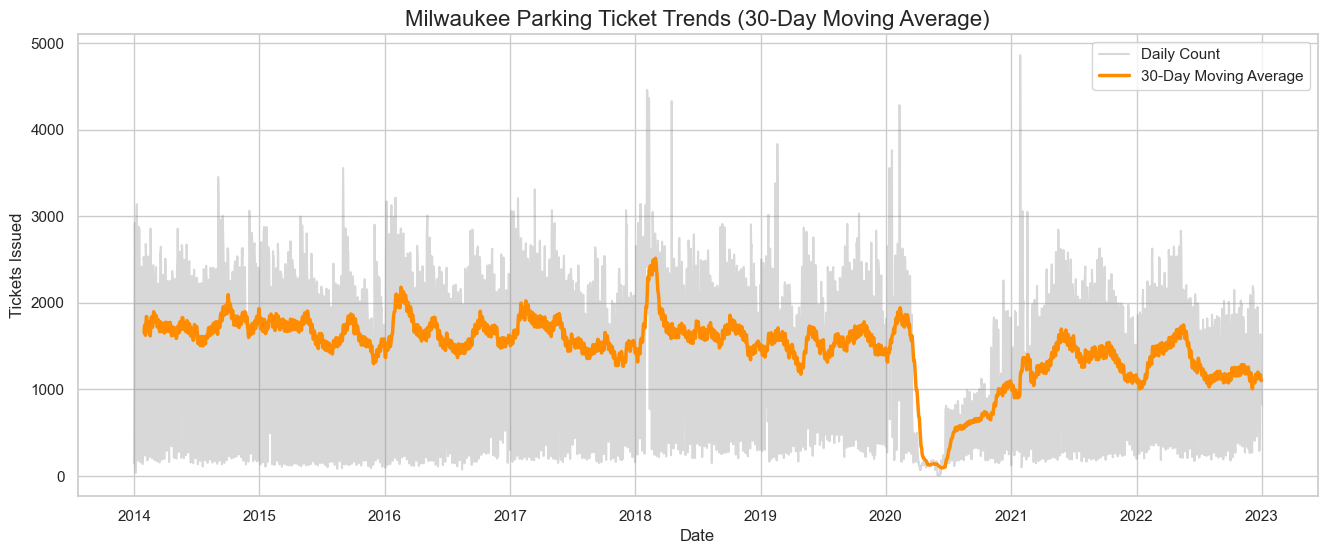

In [86]:
# Dataframe is sorted chronologically
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

# Calculate the 30-day moving average  [a single day's ticket total and 29 days prior to that Averaged]
daily_summary_df['rolling_30d_avg'] = daily_summary_df['total_tickets'].rolling(window=30).mean()


plt.figure(figsize=(16, 6))
# Plot the noisy daily data lightly in the background
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', alpha=0.3, label='Daily Count')

# Plot the smoothed 30-day average boldly on top
sns.lineplot(data=daily_summary_df, x='join_date', y='rolling_30d_avg', color='darkorange', linewidth=2.5, label='30-Day Moving Average')

plt.title("Milwaukee Parking Ticket Trends (30-Day Moving Average)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

#### Violation Sub-Count Features

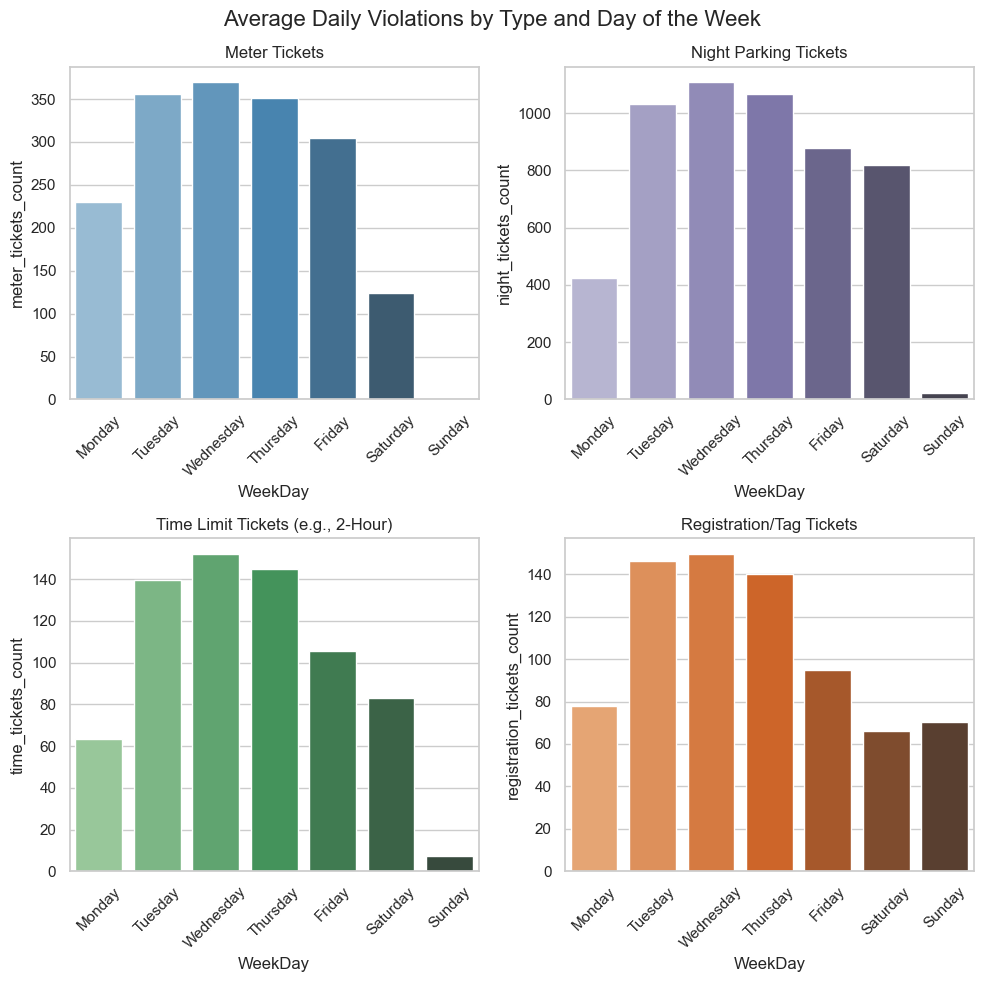

In [ ]:
# Group by weekday and calculate the mean for each sub-count
sub_counts = ['meter_tickets_count', 'night_tickets_count', 'time_tickets_count', 'registration_tickets_count']
sub_counts_grouped = daily_summary_df.groupby('WeekDay')[sub_counts].mean().reindex(days_ordered).reset_index()

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('AVERAGE Daily Violations by Type and Day of the Week', fontsize=16)

# 1. Meter Tickets
sns.barplot(ax=axes[0, 0], data=sub_counts_grouped, x='WeekDay', y='meter_tickets_count', hue='WeekDay', palette='Blues_d')
axes[0, 0].set_title('Meter Tickets')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Night Tickets
sns.barplot(ax=axes[0, 1], data=sub_counts_grouped, x='WeekDay', y='night_tickets_count', hue='WeekDay', palette='Purples_d')
axes[0, 1].set_title('Night Parking Tickets')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Time Limit Tickets
sns.barplot(ax=axes[1, 0], data=sub_counts_grouped, x='WeekDay', y='time_tickets_count', hue='WeekDay', palette='Greens_d')
axes[1, 0].set_title('Time Limit Tickets (e.g., 2-Hour)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Registration Tickets
sns.barplot(ax=axes[1, 1], data=sub_counts_grouped, x='WeekDay', y='registration_tickets_count', hue='WeekDay', palette='Oranges_d')
axes[1, 1].set_title('Registration/Tag Tickets')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Weather Features

#### Co-Linearity Tests (in Categorical and Numerical Features)